In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import json
import re
import warnings
from IPython.display import clear_output
import string
import ast
import types
from itertools import combinations, groupby, tee, permutations
from typing import Any, Tuple
import torch_geometric
import typing_extensions
from torch_geometric.utils.convert import from_networkx, to_networkx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
#from sklearn.metrics import accuracy_score


In [2]:

def model_pipeline(date: str):
    day_tph = pd.read_csv(f'october_data/day_tph_base.csv')
    day_delay = pd.read_csv(f'october_data/agg_fixed/delay_minutes_midday_{date}.csv')
    rush_tph = pd.read_csv(f'october_data/rush_tph_base.csv')
    rush_delay = pd.read_csv(f'october_data/agg_fixed/delay_minutes_rush_{date}.csv')
    f1 = open("subwaygraph_midday_dir.json",'r')
    G_day = nx.node_link_graph(json.load(f1), directed=True, multigraph=False, edges='edges')
    f2 = open("subwaygraph_rush_dir.json",'r')
    G_rush = nx.node_link_graph(json.load(f2), directed=True, multigraph=False, edges='edges')
    ews = np.unique([tuple([x[0] for x in w]) for w in G_day.edges],axis=1).tolist()
    edge_set = np.unique([tuple(e) for e in ews if e[0] != e[1]],axis=0)
    edge_set.sort(axis=1)
    edge_set = np.unique(edge_set,axis=0)
    ewsr = np.unique([tuple([x[0] for x in w]) for w in G_rush.edges],axis=1).tolist()
    edge_set_r = np.unique([tuple(e) for e in ewsr if e[0] != e[1]],axis=0)
    edge_set_r.sort(axis=1)
    edge_set_r = np.unique(edge_set_r,axis=0)
    G_day_track = nx.Graph(name='Day Tracks')
    G_day_track.add_edges_from(edge_set)
    G_rush_track = nx.Graph(name='Rush Hour Tracks')
    G_rush_track.add_edges_from(edge_set_r)
    tph_vect = day_tph.set_index('stop').to_dict('index')
    tph_vect = {k: np.array(list(v.values())) for k,v in tph_vect.items()}
    nx.set_node_attributes(G_day_track, tph_vect, 'tph')

    rush_tph_vect = rush_tph.set_index('stop').to_dict('index')
    rush_tph_vect = {k: np.array(list(v.values())) for k,v in rush_tph_vect.items()}
    nx.set_node_attributes(G_rush_track, rush_tph_vect, 'tph')

    # Define custom split ratios outside function to keep indices the same for day/rush
    train_ratio = 0.7
    val_ratio = 0.1
    test_ratio = 1.0 - train_ratio - val_ratio 
    
    num_nodes = 475

    # Shuffle node indices randomly
    random_indices = torch.randperm(num_nodes)

    # Split indices based on defined ratios
    train_idx = random_indices[:int(train_ratio * num_nodes)]
    val_idx = random_indices[int(train_ratio * num_nodes):int((train_ratio + val_ratio) * num_nodes)]
    test_idx = random_indices[int((train_ratio + val_ratio) * num_nodes):]

    def graph_network(G, y):
        subway_data = from_networkx(G, group_node_attrs='all')

        subway_data.y = torch.LongTensor(y.mins.values)
        subway_data.num_classes = len(np.unique(subway_data.y))
        

        # Create new masks for the custom split
        subway_data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
        subway_data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
        subway_data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

        # Assign nodes to the corresponding masks
        subway_data.train_mask[train_idx] = True
        subway_data.val_mask[val_idx] = True
        subway_data.test_mask[test_idx] = True

        # Display the new data split
        class OriginalGCN(torch.nn.Module):
            def __init__(self, in_channels, h1, h2, out_channels):
                super(OriginalGCN, self).__init__()
                # Using GCNConv without normalization
                self.conv1 = GCNConv(in_channels, h1, normalize=False)
                self.conv2 = GCNConv(h1, h2, normalize=False)
                self.conv3 = GCNConv(h2, out_channels, normalize=False)

            def forward(self, x, edge_index):
                x = self.conv1(x, edge_index)
                x = F.relu(x)
                x = self.conv2(x, edge_index)
                x = F.relu(x)
                x = self.conv3(x, edge_index)
                return F.log_softmax(x, dim=1)



        class NormalizedGCN(torch.nn.Module):
            def __init__(self, in_channels, h1, h2, out_channels):
                super(NormalizedGCN, self).__init__()
                # Using GCNConv with Laplacian normalization
                self.conv1 = GCNConv(in_channels, h1, normalize=True)
                self.conv2 = GCNConv(h1, h2, normalize=True)
                self.conv3 = GCNConv(h2, out_channels, normalize=True)

            def forward(self, x, edge_index):
                x = self.conv1(x, edge_index)
                x = F.relu(x)
                x = self.conv2(x, edge_index)
                x = F.relu(x)
                x = self.conv3(x, edge_index)
                return F.log_softmax(x, dim=1)


        # Instantiate model
        model_original = OriginalGCN(subway_data.num_features, 18,12, subway_data.num_classes)
        model_normalized = NormalizedGCN(subway_data.num_features, 18,12, subway_data.num_classes)

        # Define optimizers
        optimizer_original = torch.optim.Adam(model_original.parameters(), lr=0.01, weight_decay=2e-4)
        optimizer_normalized = torch.optim.Adam(model_normalized.parameters(), lr=0.01, weight_decay=2e-4)
        epochs = 140
        def train(data, model, optimizer):
            model.train()
            optimizer.zero_grad()
            out = model(data.x.type('torch.FloatTensor'), data.edge_index)
            loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()
            return loss.item()

        def validate(data, model):
            model.eval()
            with torch.no_grad():
                out = model(data.x.type('torch.FloatTensor'), data.edge_index)
                val_loss = F.nll_loss(out[data.val_mask], data.y[data.val_mask]).item()
                pred = out.argmax(dim=1)
                correct = (pred[data.val_mask] == data.y[data.val_mask]).sum().item()
                val_acc = correct / data.val_mask.sum().item()
            return val_loss, val_acc

        # Store losses for visualization
        train_losses_original = []
        train_losses_normalized = []

        # Training loop
        for epoch in range(epochs):
            # Train original model
            train_loss_original = train(subway_data, model_original, optimizer_original)
            train_losses_original.append(train_loss_original)

            # Train normalized model
            train_loss_normalized = train(subway_data, model_normalized, optimizer_normalized)
            train_losses_normalized.append(train_loss_normalized)

            # Validation every 20 epochs
            if epoch % 20 == 0:
                val_loss_original, val_acc_original = validate(subway_data, model_original)
                val_loss_normalized, val_acc_normalized = validate(subway_data, model_normalized)

                #print(f'Original GCN - Val Loss: {val_loss_original:.4f}, Val Acc: {val_acc_original:.4f}')
                #print(f'Normalized GCN - Val Loss: {val_loss_normalized:.4f}, Val Acc: {val_acc_normalized:.4f}')
    
        

        def test(data,model, name=""):
            model.eval()  # Set model to evaluation mode
            with torch.no_grad():
                out = model(data.x.type('torch.FloatTensor'), data.edge_index)  # Forward pass
                pred = out.argmax(dim=1)  # Get predicted class labels
                # Get probability scores for AUC calculation
                probas = torch.softmax(out, dim=1)

                # Extract test set data
                y_true = data.y[data.test_mask].cpu()  # Ground truth labels for test set
                y_pred = pred[data.test_mask].cpu()  # Model predictions for test set
                y_probas = probas[data.test_mask].cpu()  # Probability scores for test set

                # 1. Accuracy (Overall classification accuracy)
                # Simple metric: number of correct predictions / total number of predictions
                test_acc = accuracy_score(y_true, y_pred)

                # Print results with clear labels
                print(f"{name}:")
                print(f"Accuracy:{test_acc:.4f}")
                
        # Run the test function for both models
        print(date)
        test(subway_data, model_original, "Original GCN")
        print(date)
        test(subway_data, model_normalized, "Normalized GCN")
    

    print('Day')
    graph_network(G_day_track, day_delay)
    print('Rush Hour')
    graph_network(G_rush_track, rush_delay)
    print()

In [3]:
import os
r = re.compile('day_tph_.*')
dates = list(map(lambda w: w[8:-4], filter(r.match, os.listdir('october_data/agg_data'))))

In [4]:
dates

['09_22',
 '09_29',
 '10_06',
 '10_13',
 '10_20',
 '10_27',
 '11_03',
 '11_10',
 '11_17',
 '11_24']

In [5]:
matplotlib.style.use('default')

In [6]:
#for date in dates:
	#model_pipeline(date)

In [7]:
scoredf = pd.read_csv('tphset_out.txt')

In [8]:
dayscore = scoredf[scoredf.time=='Day']
rushscore = scoredf[scoredf.time!='Day']

In [9]:
matplotlib.style.use('default')

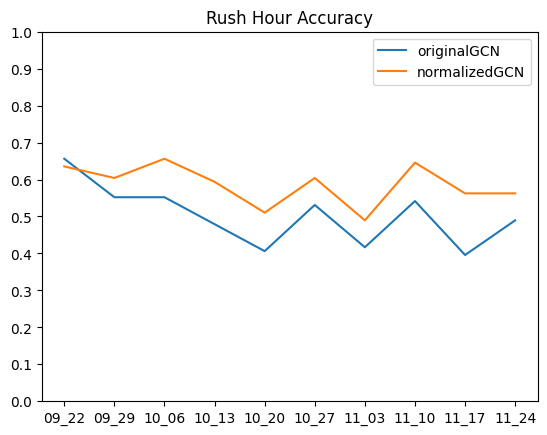

In [10]:
plt.plot(rushscore.date, rushscore.original, label='originalGCN',scaley=False)
plt.plot(rushscore.date, rushscore.normalized, label='normalizedGCN', scaley=False)
plt.yticks(np.linspace(0,1,11))
plt.legend()
plt.title('Rush Hour Accuracy')
plt.show()

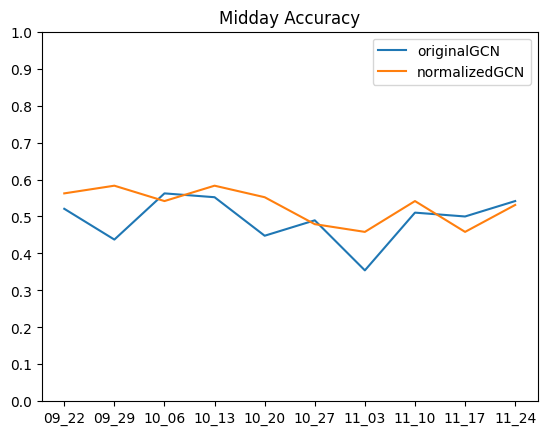

In [11]:
plt.plot(dayscore.date, dayscore.original, label='originalGCN',scaley=False)
plt.plot(dayscore.date, dayscore.normalized, label='normalizedGCN', scaley=False)
plt.yticks(np.linspace(0,1,11))
plt.legend()
plt.title("Midday Accuracy")
plt.show()

In [12]:
def setup(date):
	day_tph = pd.read_csv(f'october_data/agg_fixed/day_tph_{date}.csv')
	rush_tph = pd.read_csv(f'october_data/agg_fixed/rush_tph_{date}.csv')
	f1 = open("subwaygraph_midday_dir.json",'r')
	G_day = nx.node_link_graph(json.load(f1), directed=True, multigraph=False, edges='edges')
	f2 = open("subwaygraph_rush_dir.json",'r')
	G_rush = nx.node_link_graph(json.load(f2), directed=True, multigraph=False, edges='edges')
	ews = np.unique([tuple([x[0] for x in w]) for w in G_day.edges],axis=1).tolist()
	edge_set = np.unique([tuple(e) for e in ews if e[0] != e[1]],axis=0)
	edge_set.sort(axis=1)
	edge_set = np.unique(edge_set,axis=0)
	ewsr = np.unique([tuple([x[0] for x in w]) for w in G_rush.edges],axis=1).tolist()
	edge_set_r = np.unique([tuple(e) for e in ewsr if e[0] != e[1]],axis=0)
	edge_set_r.sort(axis=1)
	edge_set_r = np.unique(edge_set_r,axis=0)
	G_day_track = nx.Graph(name='Day Tracks')
	G_day_track.add_edges_from(edge_set)
	G_rush_track = nx.Graph(name='Rush Hour Tracks')
	G_rush_track.add_edges_from(edge_set_r)
	tph_vect = day_tph.set_index('stop').to_dict('index')
	tph_vect = {k: np.array(list(v.values())) for k,v in tph_vect.items()}
	nx.set_node_attributes(G_day_track, tph_vect, 'tph')

	rush_tph_vect = rush_tph.set_index('stop').to_dict('index')
	rush_tph_vect = {k: np.array(list(v.values())) for k,v in rush_tph_vect.items()}
	nx.set_node_attributes(G_rush_track, rush_tph_vect, 'tph')
	return G_day_track, G_rush_track

In [13]:
gdtrack, grtrack = setup('09_22')

In [14]:
line_name = [str(s) for s in [1,2,3,4,5,6,'6X',7,'7X','A','B','C','D','E','F','FS','FX','G','GS','H','J','L','M','N','Q','R','W','Z']]

In [15]:
exnodes = np.random.choice(gdtrack.nodes, 5)

In [26]:
delays = pd.read_csv('october_data/agg_fixed/delay_minutes_midday_11_10.csv',index_col='stop')

In [27]:
nx.remove_node_attributes(grtrack,'tph')

In [28]:
H = nx.relabel_nodes(grtrack, lambda w: str(w))

In [29]:
grtrack = H.copy()

In [30]:
xy = pd.read_csv('stops.csv')
xy = xy[::3][:-21].set_index('stop_id')[['stop_lat','stop_lon']]
rushnodes = pd.merge(xy,delays, left_index=True, right_index=True)
rushnodes.columns = ['x','y','mins']

In [31]:
gdtrack = nx.relabel_nodes(gdtrack, lambda w: str(w))
nx.set_node_attributes(gdtrack, rushnodes.to_dict('index'))

In [32]:
nx.set_node_attributes(grtrack, rushnodes.to_dict('index'))


In [33]:
from sklearn.preprocessing import normalize

In [34]:
rposlist = [(-(abs(grtrack.nodes[k]['y'])),grtrack.nodes[k]['x']) for k in grtrack.nodes]
dposlist =  [(-(abs(gdtrack.nodes[k]['y'])),gdtrack.nodes[k]['x']) for k in gdtrack.nodes]
dposdict = dict(zip(gdtrack.nodes, dposlist))
rposdict = dict(zip(grtrack.nodes, rposlist))

C:\Users\pacma\AppData\Local\Temp\ipykernel_7556\2846870886.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


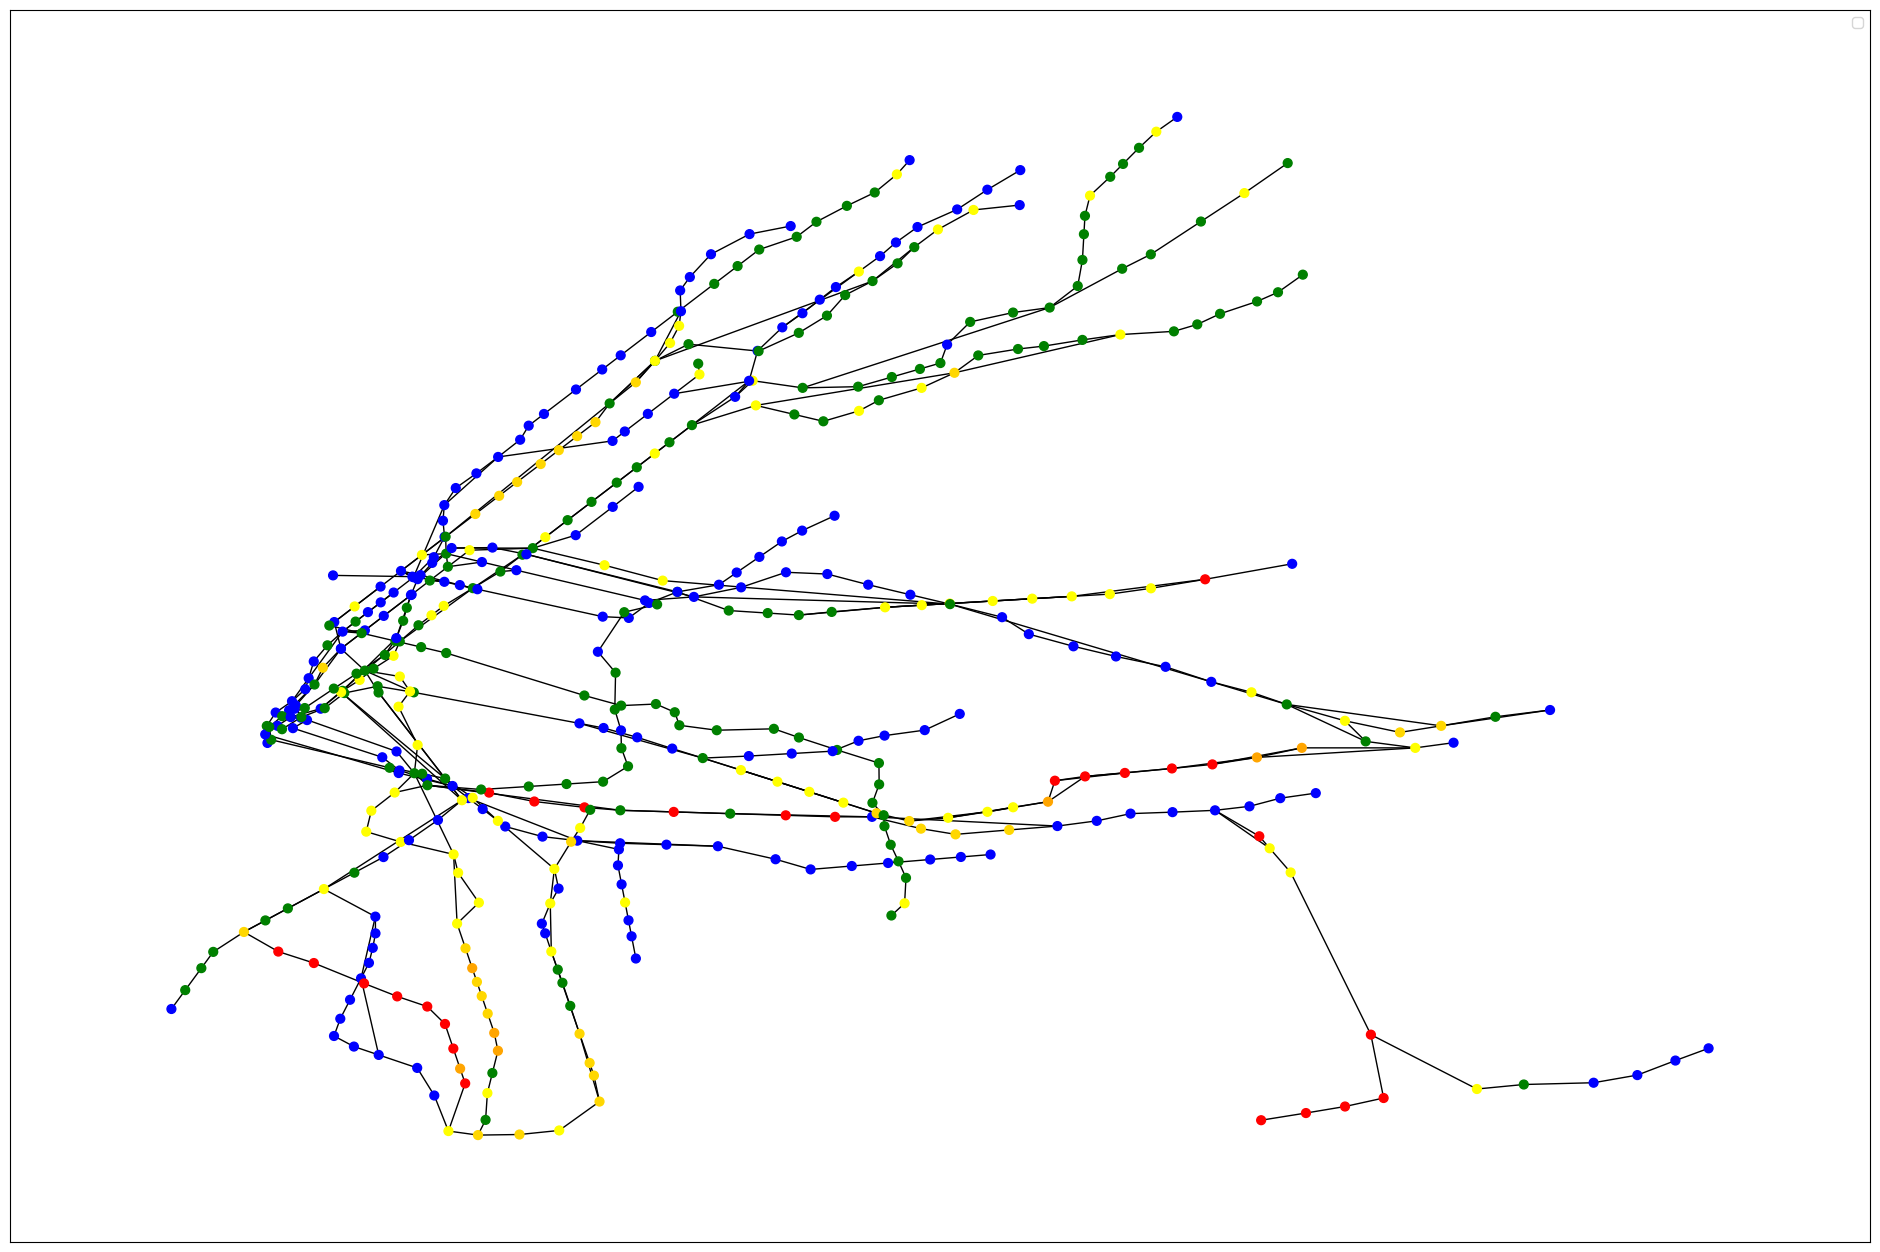

In [ ]:
colors = [['blue','green','yellow','gold','orange','red'][int(grtrack.nodes[node]['mins'])] for node in list(grtrack.nodes())]

plt.figure(figsize=(24,16))
nx.draw_networkx_nodes(grtrack, node_color=colors, pos=rposdict, node_size=40)
nx.draw_networkx_edges(grtrack,pos=rposdict,arrows=False, node_size=40)
plt.show()